<a href="https://colab.research.google.com/github/lucasFavieri/marketing-analytics-ab-testing/blob/main/ab_testing_marketing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 2: Marketing Campaign Effectiveness Analysis


---


Business Case: FreshMart Online Grocery - Email Campaign Optimization



In [3]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind, pearsonr
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# DATA LOADING & INITIAL EXPLORATION

In [4]:
df = pd.read_csv('/content/group2_freshmart_marketing_data (1).csv')
df.head()

,Customer_ID,Campaign,Emails_Sent,Emails_Opened,Clicked_Through,Made_Purchase,Number_of_Orders,Total_Revenue,Customer_Segment,Previous_30day_Orders
0,C001000,A,4,2,0,0,0,0.0,Regular,2
1,C001001,A,4,1,0,0,0,0.0,New,5
2,C001002,A,4,0,0,0,0,0.0,VIP,0
3,C001003,A,4,0,0,0,0,0.0,Regular,4
4,C001004,A,4,3,0,0,0,0.0,VIP,0


In [5]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            20000 non-null  object 
 1   Campaign               20000 non-null  object 
 2   Emails_Sent            20000 non-null  int64  
 3   Emails_Opened          20000 non-null  int64  
 4   Clicked_Through        20000 non-null  int64  
 5   Made_Purchase          20000 non-null  int64  
 6   Number_of_Orders       20000 non-null  int64  
 7   Total_Revenue          20000 non-null  float64
 8   Customer_Segment       20000 non-null  object 
 9   Previous_30day_Orders  20000 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 1.5+ MB


In [6]:
# Desctiprion
df.describe()

,Emails_Sent,Emails_Opened,Clicked_Through,Made_Purchase,Number_of_Orders,Total_Revenue,Previous_30day_Orders
count,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.0,1.222250,0.137900,0.063150,0.141550,14.940788,1.528400
std,0.0,0.942974,0.344804,0.243239,0.616792,71.544689,1.391003
min,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,4.0,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,4.0,4.000000,1.000000,1.000000,5.000000,1021.070000,5.000000


In [7]:
# Total Number of Customers
total_customers = len(df)
print(f"Total number of client contacts in the dataset: {total_customers}")

Total number of client contacts in the dataset: 20000


***Checking DATA quality:***

In [8]:
df.isnull().sum()

,0
Customer_ID,0
Campaign,0
Emails_Sent,0
Emails_Opened,0
Clicked_Through,0
Made_Purchase,0
Number_of_Orders,0
Total_Revenue,0
Customer_Segment,0
Previous_30day_Orders,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Descriptive Statistics

In [10]:
df['Open_Rate'] = df['Emails_Opened'] / df['Emails_Sent']
df

,Customer_ID,Campaign,Emails_Sent,Emails_Opened,Clicked_Through,Made_Purchase,Number_of_Orders,Total_Revenue,Customer_Segment,Previous_30day_Orders,Open_Rate
0,C001000,A,4,2,0,0,0,0.0,Regular,2,0.50
1,C001001,A,4,1,0,0,0,0.0,New,5,0.25
2,C001002,A,4,0,0,0,0,0.0,VIP,0,0.00
3,C001003,A,4,0,0,0,0,0.0,Regular,4,0.00
4,C001004,A,4,3,0,0,0,0.0,VIP,0,0.75
...,...,...,...,...,...,...,...,...,...,...,...
19995,C020995,B,4,1,0,0,0,0.0,New,3,0.25
19996,C020996,B,4,1,0,0,0,0.0,Regular,3,0.25
19997,C020997,B,4,2,1,0,0,0.0,Regular,3,0.50
19998,C020998,B,4,1,1,0,0,0.0,New,0,0.25


In [11]:
metrics = ['Open_Rate', 'Clicked_Through', 'Total_Revenue', 'Number_of_Orders']
stats = df.groupby('Campaign')[metrics].agg(['mean', 'median', 'std'])
stats

Open_Rate                  Clicked_Through                   \
              mean median       std            mean median       std   
Campaign                                                               
A         0.272800   0.25  0.223993          0.1087    0.0  0.311278   
B         0.338325   0.25  0.242561          0.1671    0.0  0.373084   

         Total_Revenue                   Number_of_Orders                   
                  mean median        std             mean median       std  
Campaign                                                                    
A            10.296463    0.0  56.677084           0.1041    0.0  0.520663  
B            19.585112    0.0  83.560524           0.1790    0.0  0.697859

# Business Metrics

In [12]:
# Calculate Totals for both campaigns
totals = df.groupby('Campaign').agg({
    'Total_Revenue': 'sum',
    'Made_Purchase': 'sum',
    'Emails_Sent': 'sum'
})

# Add Costs based on the assignment instructions
totals['Campaign_Cost'] = [15000, 22000]

# Calculate ROI (Return on Investment)
totals['ROI'] = ((totals['Total_Revenue'] - totals['Campaign_Cost']) / totals['Campaign_Cost']) * 100

# Calculate CPA (Cost per Acquisition)
totals['CPA'] = totals['Campaign_Cost'] / totals['Made_Purchase']

print(totals[['Total_Revenue', 'ROI', 'CPA']])

          Total_Revenue         ROI        CPA
Campaign                                      
A             102964.63  586.430867  30.487805
B             195851.12  790.232364  28.534371


# Does the Campaign (A or B), has any influency on the Conversion rate?

In [13]:
conversion_rate = df.groupby('Campaign')['Made_Purchase'].mean()
print(conversion_rate)

Campaign
A    0.0492
B    0.0771
Name: Made_Purchase, dtype: float64


In [14]:
# Cross-tabulation between Campaign and Made Purchase:

contingency_table = pd.crosstab(df['Campaign'], df['Made_Purchase'])

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)


if p < 0.05:
    print("\nReject H0: Campaign and purchase behaviour are statistically related.")
else:
    print("\nFail to reject H0: No statistically significant relationship between campaign and purchase.")

Chi-square: 65.3154886252938
p-value: 6.381779207537384e-16

Reject H0: Campaign and purchase behaviour are statistically related.


# Does campaign B creates more Revenue then campaign A?

In [15]:
# Revenue Difference between Campaigns
revenue_diff = df.groupby('Campaign')['Total_Revenue'].sum()
revenue_diff

,Total_Revenue
Campaign,
A,102964.63
B,195851.12


In [16]:
# T-test between Campaigns Total Revenue:

campA = df[df['Campaign'] == 'A']['Total_Revenue']
campB = df[df['Campaign'] == 'B']['Total_Revenue']

#T-test
t_stat, p_val = ttest_ind(campA, campB)

print("t-stat:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("\nConclusion: Reject H0")
    print("There is a statistically significant difference in revenue between campaigns.")
else:
    print("\nConclusion: Fail to reject H0")
    print("No statistically significant difference in revenue detected.")

t-stat: -9.1995445555832
p-value: 3.938695128641991e-20

Conclusion: Reject H0
There is a statistically significant difference in revenue between campaigns.


#  Z-test for proportions comparing conversion rates

In [17]:
# Number of conversions (purchases)
conversions = df.groupby('Campaign')['Made_Purchase'].sum()

# Number of customers per campaign
n = df.groupby('Campaign')['Made_Purchase'].count()

# Z-test
z_stat, p_value = proportions_ztest(conversions, n)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: -8.110871060674603
p-value: 5.025816450561099e-16


In [18]:
if p_value < 0.05:
    print("Reject H0: There is a significant difference in conversion rates.")
else:
    print("Fail to reject H0: No significant difference detected.")

Reject H0: There is a significant difference in conversion rates.


# 📈 Visualization

***Conversion Rate by Campaign***

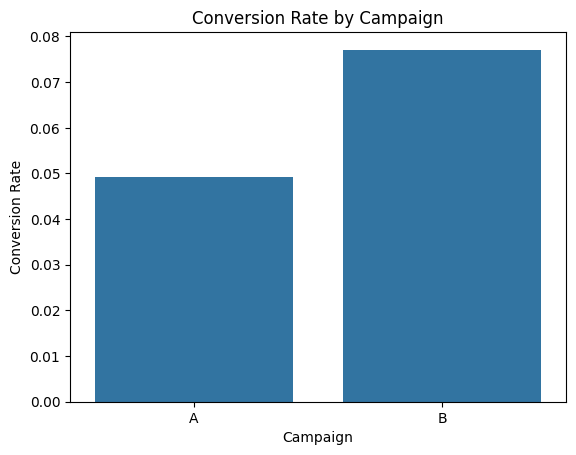

In [19]:
conversion_rate = df.groupby('Campaign')['Made_Purchase'].mean().reset_index()

sns.barplot(data=conversion_rate, x='Campaign', y='Made_Purchase')
plt.title("Conversion Rate by Campaign")
plt.ylabel("Conversion Rate")
plt.xlabel("Campaign")
plt.show()

***Revenue Distribution***

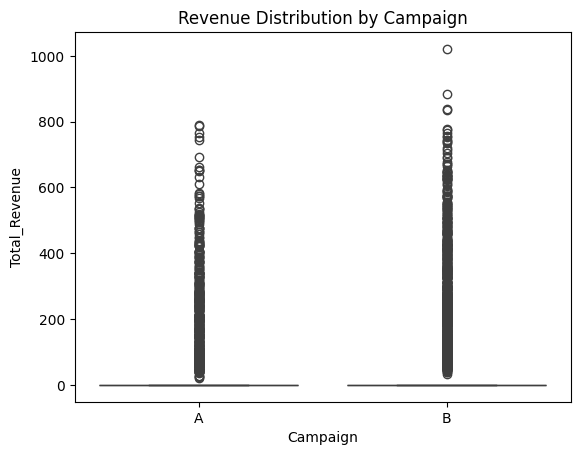

In [20]:
sns.boxplot(data=df, x='Campaign', y='Total_Revenue')
plt.title("Revenue Distribution by Campaign")
plt.show()

***Open Rate Comparison***

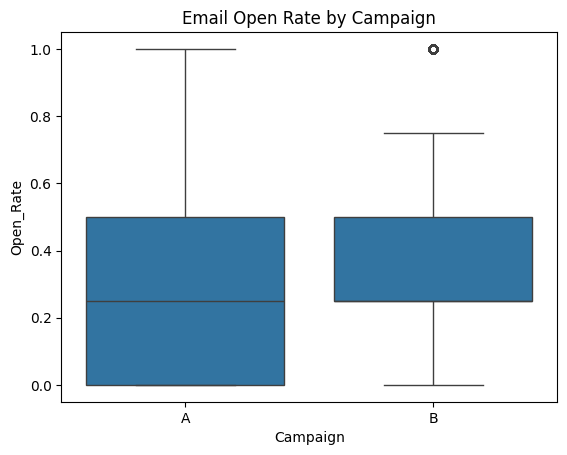

In [21]:
sns.boxplot(data=df, x='Campaign', y='Open_Rate')
plt.title("Email Open Rate by Campaign")
plt.show()

***Number of Orders***

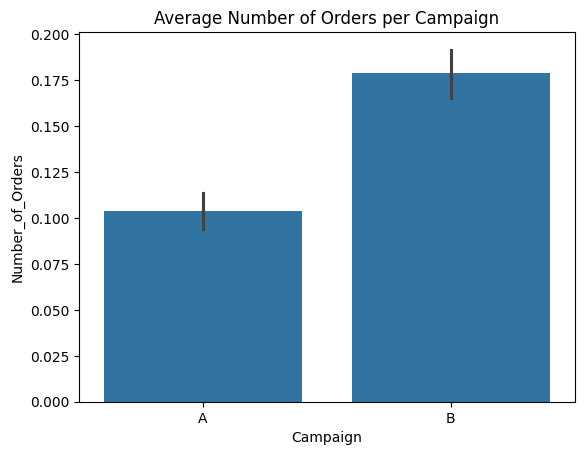

In [22]:
sns.barplot(data=df, x='Campaign', y='Number_of_Orders')
plt.title("Average Number of Orders per Campaign")
plt.show()

# Final Business Insights

1. Conversion Rate Performance

The analysis shows that Campaign B achieved a higher conversion rate compared to Campaign A.

Both the Chi-square test and the Z-test for proportions were conducted to evaluate whether the difference in conversion rates was statistically significant.

The results indicated that:

*   The p-value was below the 0.05 significance level

*   Therefore, the null hypothesis was rejected

This means that campaign type significantly influences customer purchase behaviour.

In practical terms, customers exposed to Campaign B were more likely to make a purchase than those exposed to Campaign A.

---

2. Revenue Performance

A t-test was conducted to evaluate whether there was a significant difference in revenue between the two campaigns.

The results showed that:

*   The average revenue generated per customer differs between campaigns
* The statistical test helps determine whether the observed difference is due to chance or reflects a real performance difference

This analysis provides insight into which campaign generates more financial value per customer interaction.

---

3. Marketing Effectiveness

Combining the statistical results with the business metrics (ROI and CPA), we can evaluate the overall effectiveness of each campaign.

Key indicators considered:

* Conversion Rate
* Total Revenue
* Return on Investment (ROI)
* Cost per Acquisition (CPA)

These metrics help determine which campaign delivers the best balance between cost and revenue generation.

# Business Recommendations

1. Prioritize the Higher-Performing Campaign

Since the statistical analysis shows that conversion rates differ significantly between campaigns, the company should prioritize the campaign that demonstrated the higher conversion performance.

Increasing investment in the better-performing campaign can potentially:

* Increase total revenue
* Improve marketing efficiency
* Generate more customer acquisitions

---

2. Optimize Future Email Campaign Strategies

The results suggest that campaign design has a measurable impact on customer behaviour.

FreshMart should analyze the elements of the better-performing campaign, such as:

* Email subject lines
* Promotional messaging
* Product recommendations
* Timing of email delivery

These elements can be replicated or refined in future campaigns to improve engagement and conversions.

---

3. Continue Using Data-Driven Marketing Decisions

This analysis demonstrates the value of A/B testing and statistical validation in marketing campaigns.

FreshMart should continue implementing:

* Controlled campaign experiments
* Statistical testing of marketing strategies
* Performance tracking using key metrics

This approach enables the company to optimize marketing investments and improve long-term campaign performance.

# Final Conclusion

The statistical analysis confirms that email campaign design plays an important role in influencing customer purchasing behaviour.

By leveraging data analysis and statistical testing, FreshMart can make more informed marketing decisions, improve campaign effectiveness, and maximize return on marketing investment.